# SHAP Prism: fully synthetic quick start

Run this notebook directly in Google Colab or from a SHAP Prism source
checkout. In Colab, the first code cell installs exactly `shap-prism==0.4.4`
from PyPI. In a source checkout, it uses the checked-out package instead.

The notebook generates its feature matrix and additive contribution matrix in
memory. It downloads, reads, or redistributes no empirical data. The example
shows both the categorical-aware global summary and the subgroup Prism view.

In [1]:
import os
from pathlib import Path
import subprocess
import sys

EXPECTED_VERSION = "0.4.4"

if sys.version_info < (3, 12):
    raise RuntimeError("SHAP Prism 0.4.4 requires Python 3.12 or newer.")


def find_source_checkout(start: Path) -> Path | None:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src/shap_prism"
        ).is_dir():
            return candidate
    return None


SOURCE_ROOT = find_source_checkout(Path.cwd().resolve())
if SOURCE_ROOT is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--disable-pip-version-check",
            "--no-cache-dir",
            "--index-url",
            "https://pypi.org/simple",
            f"shap-prism=={EXPECTED_VERSION}",
        ],
        check=True,
    )
    INSTALL_SOURCE = "PyPI"
    OUTPUT_DIR = Path("shap_prism_output")
else:
    os.chdir(SOURCE_ROOT)
    sys.path.insert(0, str(SOURCE_ROOT / "src"))
    INSTALL_SOURCE = "repository checkout"
    OUTPUT_DIR = Path("notebooks/output")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Environment ready: {INSTALL_SOURCE}")

Environment ready: repository checkout


## Build a deterministic synthetic example

The synthetic output is the sum of a baseline and five known feature
contributions. For this additive construction, the contribution matrix is
already aligned and ready for SHAP Prism. The plotting package does not fit a
model or estimate explanations.

`Acquisition channel` deliberately has ten levels. SHAP Prism keeps seven raw
levels under its documented frequency-and-tie rule and pools the remaining
levels into `Others`, preserving all rows while keeping an eight-entry
categorical key.

In [2]:
import json
import tempfile

os.environ["SOURCE_DATE_EPOCH"] = "1784332800"
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "shap-prism-mpl"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shap_prism import __version__, plot_prism, plot_summary

assert __version__ == EXPECTED_VERSION

RANDOM_STATE = 4701
rng = np.random.default_rng(RANDOM_STATE)
n_rows = 240

segment_values = np.repeat(["North", "Central", "South"], 80)
rng.shuffle(segment_values)

channel_levels = [f"C{index:02d}" for index in range(1, 11)]
channel_counts = [36, 32, 28, 26, 24, 22, 20, 18, 17, 17]
channel_values = np.concatenate(
    [np.repeat(level, count) for level, count in zip(channel_levels, channel_counts)]
)
rng.shuffle(channel_values)

risk_levels = ["Low", "Moderate", "High", "Critical"]
risk_values = np.tile(risk_levels, n_rows // len(risk_levels))
rng.shuffle(risk_values)

exposure = rng.normal(0.0, 1.0, n_rows)
stability = rng.beta(3.0, 2.0, n_rows)

features = pd.DataFrame(
    {
        "Exposure": exposure,
        "Stability": stability,
        "Acquisition channel": pd.Categorical(
            channel_values, categories=channel_levels, ordered=True
        ),
        "Risk band": pd.Categorical(
            risk_values, categories=risk_levels, ordered=True
        ),
        "Segment": pd.Categorical(
            segment_values, categories=["North", "Central", "South"], ordered=True
        ),
    }
)

channel_effect = dict(zip(channel_levels, np.linspace(-0.42, 0.42, 10)))
risk_effect = {"Low": -0.62, "Moderate": -0.16, "High": 0.28, "Critical": 0.72}
segment_effect = {"North": -0.18, "Central": 0.02, "South": 0.22}

shap_values = pd.DataFrame(
    {
        "Exposure": 0.68 * exposure,
        "Stability": -0.82 * (stability - stability.mean()),
        "Acquisition channel": np.array([channel_effect[value] for value in channel_values]),
        "Risk band": np.array([risk_effect[value] for value in risk_values]),
        "Segment": np.array([segment_effect[value] for value in segment_values]),
    }
)

baseline = 1.25
synthetic_output = baseline + shap_values.sum(axis=1)
groups = features["Segment"].copy()

assert features.shape == shap_values.shape == (240, 5)
assert features.index.equals(shap_values.index)
assert features.columns.equals(shap_values.columns)
assert np.isfinite(shap_values.to_numpy(float)).all()
assert np.allclose(baseline + shap_values.sum(axis=1), synthetic_output)

print(f"shap-prism {__version__}")
print(f"synthetic feature and contribution matrices: {features.shape}")
print(f"group counts: {groups.value_counts(sort=False).to_dict()}")
print("No external or empirical data were loaded.")

shap-prism 0.4.4
synthetic feature and contribution matrices: (240, 5)
group counts: {'North': 80, 'Central': 80, 'South': 80}
No external or empirical data were loaded.


## 1. Categorical-aware global summary

The category keys are stacked from the upper right downward. Continuous rows
retain the continuous color map. The ten-level channel row appears as seven
retained levels plus `Others`.

feature order: ['Exposure', 'Risk band', 'Acquisition channel', 'Segment', 'Stability']
saved: ['notebooks/output/synthetic_shap_summary.png', 'notebooks/output/synthetic_shap_summary.pdf']


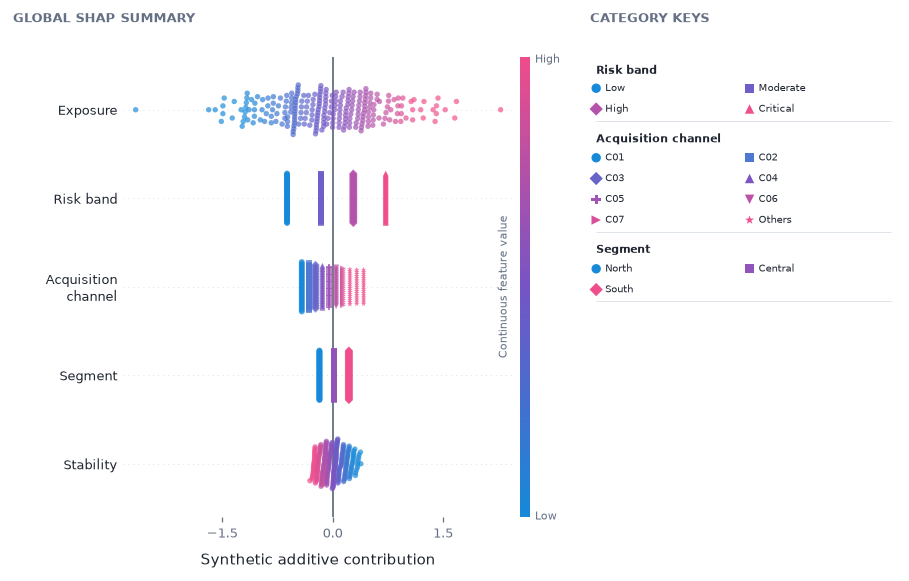

In [3]:
SUMMARY_STEM = OUTPUT_DIR / "synthetic_shap_summary"

summary_result = plot_summary(
    shap_values,
    features,
    category_order_mode="data",
    category_key_placement="right_stacked",
    x_label="Synthetic additive contribution",
    max_features=5,
    random_state=RANDOM_STATE,
    output=SUMMARY_STEM,
)

print("feature order:", summary_result.summary["global_feature_order"])
print("saved:", summary_result.summary["output_files"])
summary_result.figure

## 2. SHAP Prism subgroup view

The right panel expands `Risk band` across three analyst-declared segments.
Every subgroup uses one shared contribution scale, and hollow diamonds show
signed means computed from all rows.

group counts: {'North': 80, 'Central': 80, 'South': 80}
saved: ['notebooks/output/synthetic_shap_prism.png', 'notebooks/output/synthetic_shap_prism.pdf']


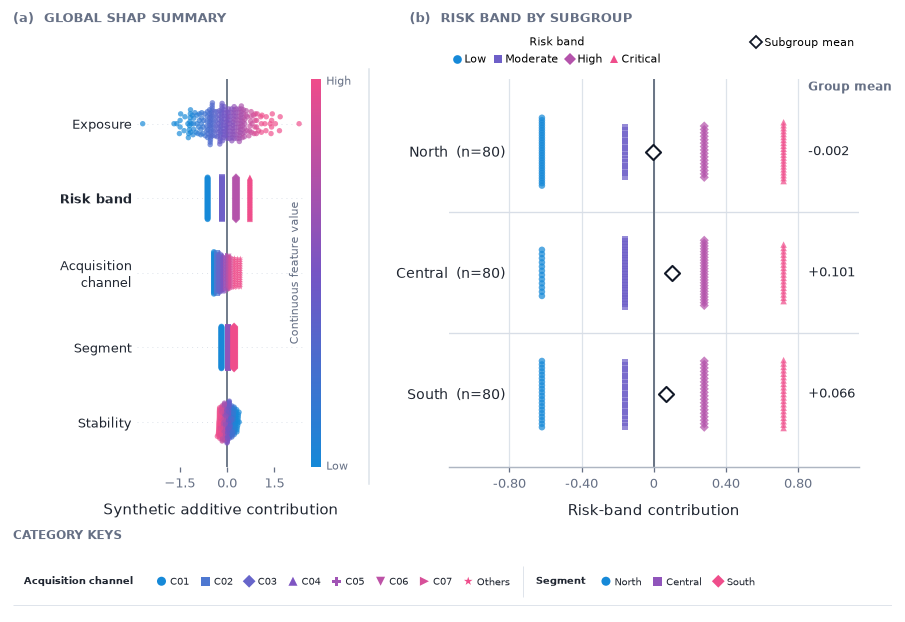

In [4]:
PRISM_STEM = OUTPUT_DIR / "synthetic_shap_prism"

prism_result = plot_prism(
    shap_values,
    features,
    groups=groups,
    focal_feature="Risk band",
    focal_kind="categorical",
    group_order=["North", "Central", "South"],
    category_order=risk_levels,
    category_order_mode="data",
    global_x_label="Synthetic additive contribution",
    local_x_label="Risk-band contribution",
    focal_value_label="Risk band",
    max_global_features=5,
    show_mean=True,
    random_state=RANDOM_STATE,
    output=PRISM_STEM,
)

print("group counts:", prism_result.summary["group_counts"])
print("saved:", prism_result.summary["output_files"])
prism_result.figure

## 3. Save the machine-readable rendering records

A suffix-free output stem writes both PNG and hybrid PDF. The returned summary
is JSON-safe and records the resolved ordering, category encodings, limits,
sampling, and output paths.

In [5]:
SUMMARY_JSON = OUTPUT_DIR / "synthetic_shap_summary.json"
PRISM_JSON = OUTPUT_DIR / "synthetic_shap_prism_summary.json"

for result, target in (
    (summary_result, SUMMARY_JSON),
    (prism_result, PRISM_JSON),
):
    target.write_text(
        json.dumps(result.summary, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )

expected_outputs = [
    SUMMARY_STEM.with_suffix(".png"),
    SUMMARY_STEM.with_suffix(".pdf"),
    SUMMARY_JSON,
    PRISM_STEM.with_suffix(".png"),
    PRISM_STEM.with_suffix(".pdf"),
    PRISM_JSON,
]
assert all(path.is_file() and path.stat().st_size > 0 for path in expected_outputs)
summary_record = json.loads(SUMMARY_JSON.read_text(encoding="utf-8"))
assert summary_record["n_features"] == 5
channel_key = summary_record["global_category_keys"]["Acquisition channel"]
assert channel_key["levels"] == channel_levels[:7] + ["Others"]
assert channel_key["retained_level_row_counts"] == channel_counts[:7]
assert channel_key["collapsed_levels"] == channel_levels[7:]
assert channel_key["collapsed_row_count"] == sum(channel_counts[7:])
assert json.loads(PRISM_JSON.read_text(encoding="utf-8"))["group_counts"] == {
    "North": 80,
    "Central": 80,
    "South": 80,
}

print("verified synthetic outputs:")
for path in expected_outputs:
    print(f"  {path} ({path.stat().st_size:,} bytes)")

plt.close(summary_result.figure)
plt.close(prism_result.figure)

verified synthetic outputs:
  notebooks/output/synthetic_shap_summary.png (216,185 bytes)
  notebooks/output/synthetic_shap_summary.pdf (224,875 bytes)
  notebooks/output/synthetic_shap_summary.json (6,344 bytes)
  notebooks/output/synthetic_shap_prism.png (255,548 bytes)
  notebooks/output/synthetic_shap_prism.pdf (216,746 bytes)
  notebooks/output/synthetic_shap_prism_summary.json (9,095 bytes)


## Interpretation boundary

Horizontal position is a synthetic additive contribution. Vertical spread
only prevents overlap; it is not a density estimate. Colors and markers
identify categorical values. The subgroup comparison is descriptive, not
causal, inferential, or a fairness assessment.

Replace the synthetic matrices with aligned explanations from one documented
model output before using SHAP Prism in an empirical analysis.